<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
## Write your code here
# 1. Print the shape of the dataset (rows, columns)
print(f"Dataset Shape: {df.shape}\n")

# 2. Display summary information about columns, data types, and missing values
print("Dataset Info:")
df.info(verbose=True, show_counts=True)

Dataset Shape: (65437, 114)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Data columns (total 114 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    ResponseId                      65437 non-null  int64  
 1    MainBranch                      65437 non-null  str    
 2    Age                             65437 non-null  str    
 3    Employment                      65437 non-null  str    
 4    RemoteWork                      54806 non-null  str    
 5    Check                           65437 non-null  str    
 6    CodingActivities                54466 non-null  str    
 7    EdLevel                         60784 non-null  str    
 8    LearnCode                       60488 non-null  str    
 9    LearnCodeOnline                 49237 non-null  str    
 10   TechDoc                         40897 non-null  str    
 11   YearsCode                       59869 non-null

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
## Write your code here
# 1. Check the number of missing values in the critical columns
print("Missing values before cleaning:")
print(df[['Employment', 'JobSat', 'RemoteWork']].isnull().sum())

# 2. Drop rows where any of these critical columns have missing values
df.dropna(subset=['Employment', 'JobSat', 'RemoteWork'], inplace=True)

# 3. Verify that the missing values have been removed
print("\nMissing values after cleaning:")
print(df[['Employment', 'JobSat', 'RemoteWork']].isnull().sum())

Missing values before cleaning:
Employment        0
JobSat        36311
RemoteWork    10631
dtype: int64

Missing values after cleaning:
Employment    0
JobSat        0
RemoteWork    0
dtype: int64


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [5]:
## Write your code here
# Calculate and display value counts for Employment
print("=== Employment Distribution ===")
print(df['Employment'].value_counts())
print("\n" + "="*30 + "\n")

# Calculate and display value counts for JobSat
print("=== Job Satisfaction Distribution ===")
print(df['JobSat'].value_counts())
print("\n" + "="*30 + "\n")

# Calculate and display value counts for YearsCodePro
print("=== Professional Coding Experience Distribution ===")
print(df['YearsCodePro'].value_counts())

=== Employment Distribution ===
Employment
Employed, full-time                                                                                                               22534
Employed, full-time;Independent contractor, freelancer, or self-employed                                                           2291
Independent contractor, freelancer, or self-employed                                                                               1244
Employed, part-time                                                                                                                 533
Employed, full-time;Student, part-time                                                                                              509
                                                                                                                                  ...  
Employed, full-time;Not employed, but looking for work;Not employed, and not looking for work;Employed, part-time                     1
Stude

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


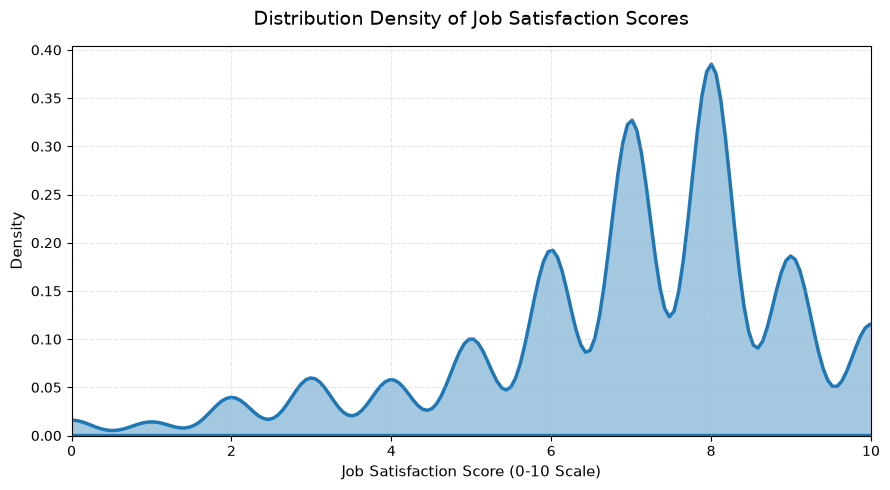

In [6]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure JobSat is numeric and drop any missing rows for this visual
df_sat = df.dropna(subset=['JobSat']).copy()
df_sat['JobSat'] = pd.to_numeric(df_sat['JobSat'], errors='coerce')
df_sat = df_sat.dropna(subset=['JobSat'])

# 2. Create a clean KDE (Kernel Density Estimate) plot
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df_sat, x='JobSat', fill=True, color='#1f77b4', linewidth=2.5, alpha=0.4)

plt.title('Distribution Density of Job Satisfaction Scores', fontsize=14, pad=15)
plt.xlabel('Job Satisfaction Score (0-10 Scale)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


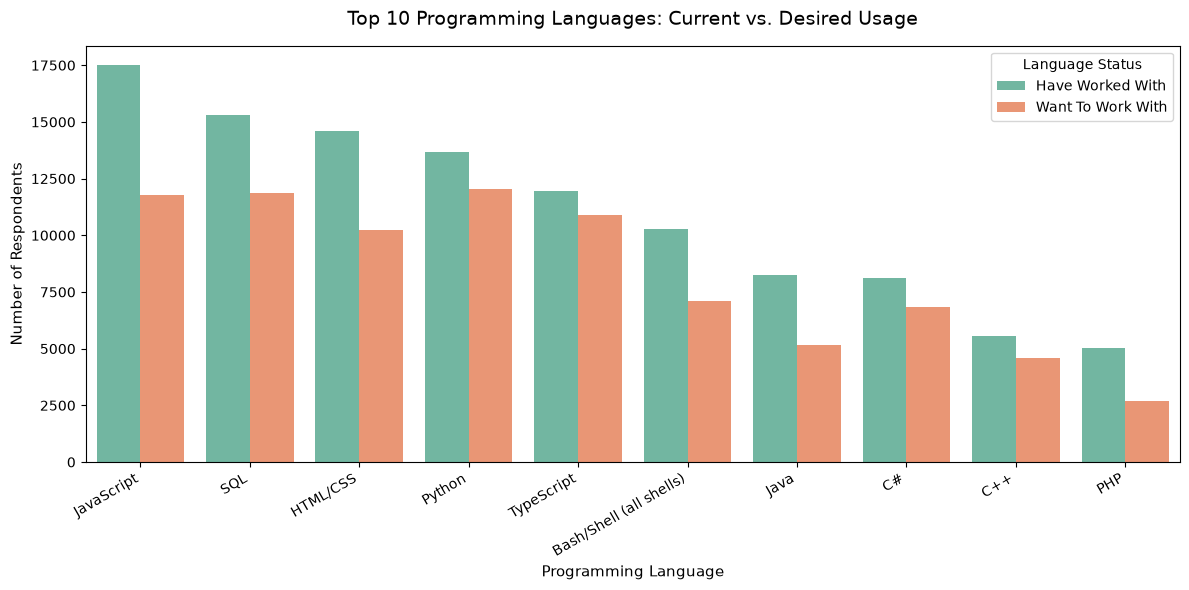

In [8]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Drop rows missing language data and copy
df_lang = df.dropna(subset=['LanguageHaveWorkedWith', 'LanguageWantToWorkWith']).copy()

# 2. Split, explode, count, and cleanly format 'Have Worked With'
worked_languages = df_lang['LanguageHaveWorkedWith'].str.split(';').explode()
worked_counts = worked_languages.value_counts().reset_index()
worked_counts.columns = ['Language', 'Have Worked With']

# 3. Split, explode, count, and cleanly format 'Want To Work With'
want_languages = df_lang['LanguageWantToWorkWith'].str.split(';').explode()
want_counts = want_languages.value_counts().reset_index()
want_counts.columns = ['Language', 'Want To Work With']

# 4. Merge the two counts together on 'Language' and grab the top 10
lang_compare = pd.merge(worked_counts, want_counts, on='Language')
top_10_langs = lang_compare.nlargest(10, 'Have Worked With')

# 5. Melt the dataframe to make it compatible with Seaborn's grouped bar plot format
lang_melted = pd.melt(
    top_10_langs, 
    id_vars=['Language'], 
    value_vars=['Have Worked With', 'Want To Work With'],
    var_name='Status', 
    value_name='Count'
)

# 6. Plot the grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=lang_melted, x='Language', y='Count', hue='Status', palette='Set2')

plt.title('Top 10 Programming Languages: Current vs. Desired Usage', fontsize=14, pad=15)
plt.xlabel('Programming Language', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Language Status')
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


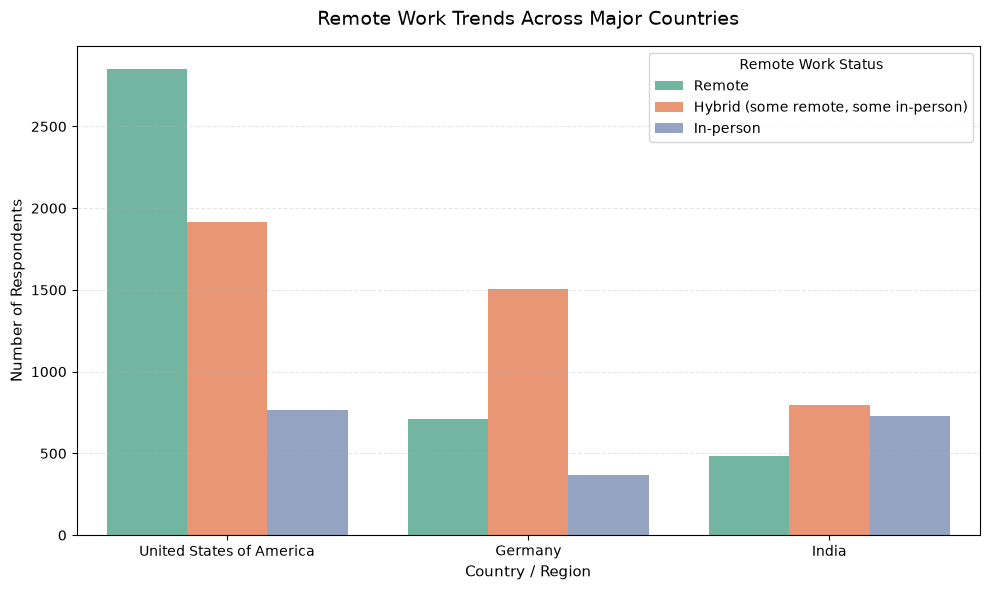

In [9]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean up missing values for RemoteWork and Country
df_remote_trend = df.dropna(subset=['RemoteWork', 'Country']).copy()

# 2. Identify the top 3 countries with the most data points
top_3_countries = df_remote_trend['Country'].value_counts().nlargest(3).index.tolist()
df_top_countries = df_remote_trend[df_remote_trend['Country'].isin(top_3_countries)]

# 3. Create a clean grouped count plot (explicitly setting hue to avoid future warnings)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_top_countries, 
    x='Country', 
    hue='RemoteWork', 
    palette='Set2',
    order=top_3_countries
)

plt.title('Remote Work Trends Across Major Countries', fontsize=14, pad=15)
plt.xlabel('Country / Region', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)
plt.legend(title='Remote Work Status', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


Pearson Correlation Coefficient: 0.1032


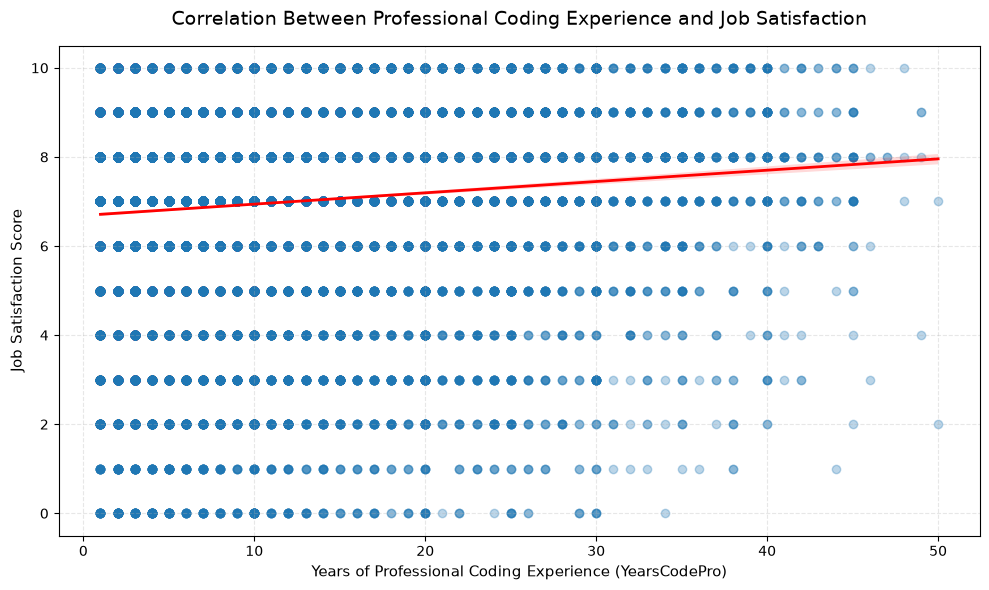

In [10]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean and convert columns to numeric, handling string edge cases safely
df_corr = df.dropna(subset=['JobSat', 'YearsCodePro']).copy()
df_corr['JobSat'] = pd.to_numeric(df_corr['JobSat'], errors='coerce')
df_corr['YearsCodePro'] = pd.to_numeric(df_corr['YearsCodePro'], errors='coerce')

# Drop any rows that became NaN during conversion
df_corr = df_corr.dropna(subset=['JobSat', 'YearsCodePro'])

# 2. Calculate the Pearson correlation coefficient
pearson_corr = df_corr['YearsCodePro'].corr(df_corr['JobSat'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.4f}")

# 3. Plot the relationship using a regression plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_corr, 
    x='YearsCodePro', 
    y='JobSat', 
    scatter_kws={'alpha': 0.3, 'color': '#1f77b4'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Correlation Between Professional Coding Experience and Job Satisfaction', fontsize=14, pad=15)
plt.xlabel('Years of Professional Coding Experience (YearsCodePro)', fontsize=11)
plt.ylabel('Job Satisfaction Score', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Cross-tabulation of Education Level vs Employment Type (Percentages):
Employment_Clean        Freelancer/Contractor  Full-time  Part-time
EdLevel_Clean                                                      
Bachelor's                               4.44      93.32       2.23
Doctorate/Professional                   4.85      92.43       2.71
High School/Associate                    6.60      88.09       5.31
Master's                                 5.87      91.58       2.54
Other                                    6.86      89.83       3.31


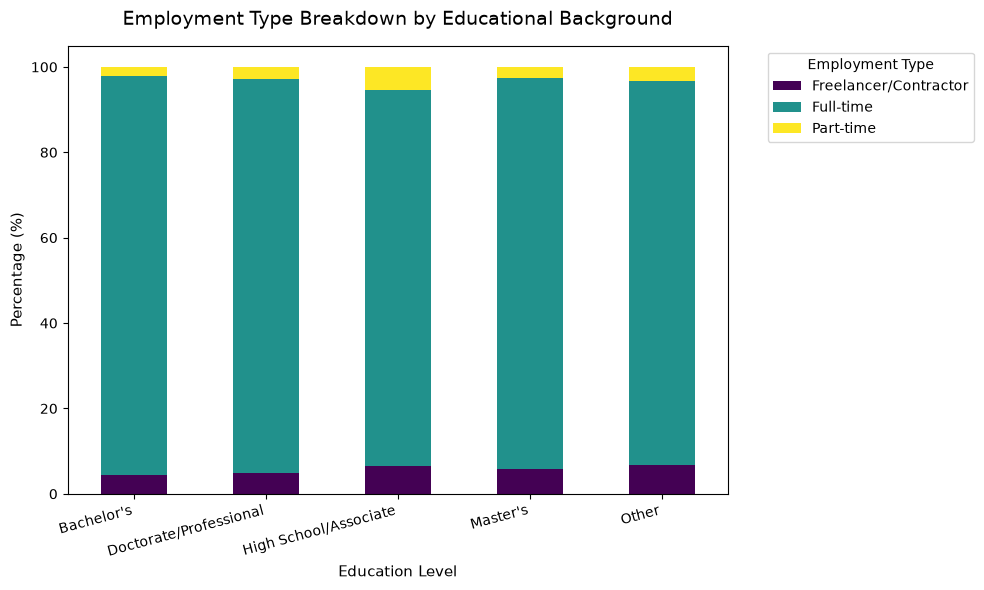

In [11]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean up missing values for our target columns
df_cross = df.dropna(subset=['EdLevel', 'Employment']).copy()

# 2. Simplify EdLevel strings to make the plot labels readable
def simplify_edu(edu_string):
    edu_lower = str(edu_string).lower()
    if 'bachelor' in edu_lower:
        return "Bachelor's"
    elif 'master' in edu_lower:
        return "Master's"
    elif 'professional degree' in edu_lower or 'phd' in edu_lower or 'doctor' in edu_lower:
        return 'Doctorate/Professional'
    elif 'associate' in edu_lower or 'secondary' in edu_lower or 'high school' in edu_lower:
        return 'High School/Associate'
    else:
        return 'Other'

df_cross['EdLevel_Clean'] = df_cross['EdLevel'].apply(simplify_edu)

# 3. Simplify Employment strings to prevent overcrowded legends
def simplify_employment(emp_string):
    emp_lower = str(emp_string).lower()
    if 'full-time' in emp_lower:
        return 'Full-time'
    elif 'independent contractor' in emp_lower or 'freelancer' in emp_lower:
        return 'Freelancer/Contractor'
    elif 'part-time' in emp_lower:
        return 'Part-time'
    else:
        return 'Other'

df_cross['Employment_Clean'] = df_cross['Employment'].apply(simplify_employment)

# 4. Generate the Cross-tabulation table (normalized by row to show percentages)
print("Cross-tabulation of Education Level vs Employment Type (Percentages):")
edu_crosstab = pd.crosstab(df_cross['EdLevel_Clean'], df_cross['Employment_Clean'], normalize='index') * 100
print(edu_crosstab.round(2))

# 5. Visualize with a clean, structured stacked bar plot
edu_crosstab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Employment Type Breakdown by Educational Background', fontsize=14, pad=15)
plt.sidebar = False
plt.xlabel('Education Level', fontsize=11)
plt.ylabel('Percentage (%)', fontsize=11)
plt.xticks(rotation=15, ha='right')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [12]:
## Write your code here
# Save the cleaned dataframe to a new CSV file
df.to_csv('clean_survey_data.csv', index=False)

print("Success! Your cleaned dataset has been successfully saved as 'clean_survey_data.csv'.")

Success! Your cleaned dataset has been successfully saved as 'clean_survey_data.csv'.


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
